# Q2: Sampling and Bootstrap on Diabetes Data

The `diabetes.csv` file has 768 patients and 9 columns. We treat the whole file as the population and compare sample-level statistics to population-level statistics for three variables: Glucose, BMI, and BloodPressure.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

pop = pd.read_csv('data/diabetes.csv')
pop.shape

(768, 9)

## (a) Random sample of 25: Glucose mean and max (5 pts)

Seed fixed at 42 so the sample is reproducible. The sample of 25 patients is a small slice of the 768-person population, so some drift from the population values is expected.

In [2]:
sample_a = pop.sample(n=25, random_state=RNG_SEED)

glu_stats = pd.DataFrame({
    'population': [pop['Glucose'].mean(), pop['Glucose'].max()],
    'sample_n25': [sample_a['Glucose'].mean(), sample_a['Glucose'].max()],
}, index=['mean', 'max']).round(2)
glu_stats

,population,sample_n25
mean,120.89,116.64
max,199.00,183.00


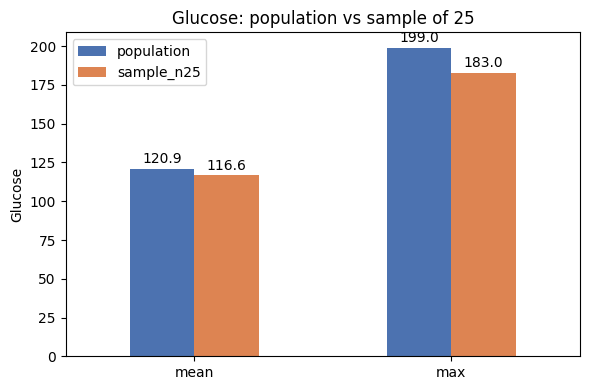

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
glu_stats.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'])
ax.set_title('Glucose: population vs sample of 25')
ax.set_ylabel('Glucose')
ax.set_xticklabels(glu_stats.index, rotation=0)
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f', padding=2)
plt.tight_layout()
plt.savefig('figures/q2a_glucose.png', dpi=120)
plt.show()

**Findings (a).** The sample mean is close to the population mean, but the sample max is a bit lower. That is expected: an extreme value in the population is only caught by a sample of 25 if we happen to draw it. The mean is the statistic that stabilizes fastest with small samples; order statistics like the max are the least stable.

## (b) 98th percentile of BMI (5 pts)

Same sample as part (a). I compare the 98th percentile of BMI in the sample to the 98th percentile in the population.

In [4]:
bmi_stats = pd.DataFrame({
    'population': [np.percentile(pop['BMI'], 98)],
    'sample_n25': [np.percentile(sample_a['BMI'], 98)],
}, index=['p98']).round(2)
bmi_stats

,population,sample_n25
p98,47.53,40.25


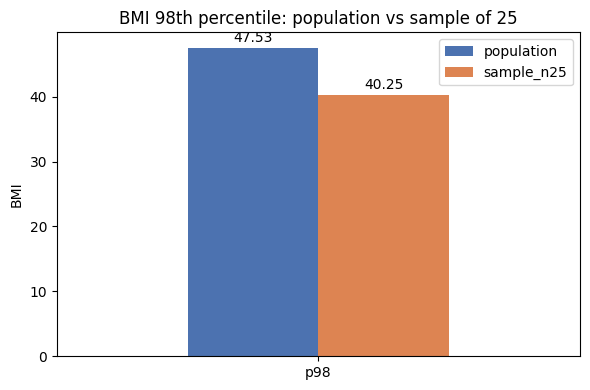

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
bmi_stats.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'])
ax.set_title('BMI 98th percentile: population vs sample of 25')
ax.set_ylabel('BMI')
ax.set_xticklabels(bmi_stats.index, rotation=0)
for c in ax.containers:
    ax.bar_label(c, fmt='%.2f', padding=2)
plt.tight_layout()
plt.savefig('figures/q2b_bmi_p98.png', dpi=120)
plt.show()

**Findings (b).** A 98th percentile on 25 points is effectively the top one or two observations, so the sample estimate swings a lot. It can land above or below the population value depending on which tail observations happened to be drawn. This is a known weakness of extreme-quantile estimation on small samples.

## (c) Bootstrap for BloodPressure (10 pts)

Draw 500 bootstrap samples of size 150 with replacement. For each sample, compute mean, standard deviation, and the 98th percentile of BloodPressure. Then take the average across the 500 samples and compare to the population values.

In [6]:
n_boot = 500
boot_n = 150
boot_rng = np.random.default_rng(RNG_SEED)

means, stds, p98s = [], [], []
bp_values = pop['BloodPressure'].to_numpy()
for _ in range(n_boot):
    idx = boot_rng.integers(0, len(bp_values), size=boot_n)
    s = bp_values[idx]
    means.append(s.mean())
    stds.append(s.std(ddof=1))
    p98s.append(np.percentile(s, 98))

boot = pd.DataFrame({'mean': means, 'std': stds, 'p98': p98s})
boot.describe().round(3)

,mean,std,p98
count,500.000,500.000,500.000
mean,69.136,19.047,97.888
std,1.530,2.173,4.931
min,63.847,11.879,88.080
25%,68.118,17.713,94.040
50%,69.237,19.061,96.180
75%,70.242,20.505,100.160
max,73.067,25.813,110.080


In [7]:
pop_stats = {
    'mean': pop['BloodPressure'].mean(),
    'std':  pop['BloodPressure'].std(ddof=1),
    'p98':  np.percentile(pop['BloodPressure'], 98),
}

compare = pd.DataFrame({
    'population':      [pop_stats['mean'], pop_stats['std'], pop_stats['p98']],
    'bootstrap_avg':   [boot['mean'].mean(), boot['std'].mean(), boot['p98'].mean()],
}, index=['mean', 'std', 'p98']).round(3)
compare

,population,bootstrap_avg
mean,69.105,69.136
std,19.356,19.047
p98,99.320,97.888


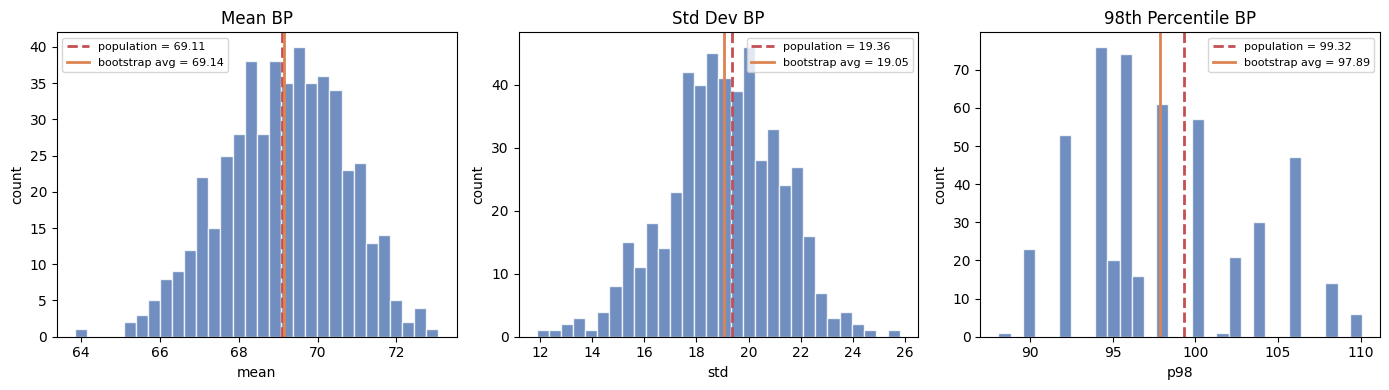

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
names = ['mean', 'std', 'p98']
titles = ['Mean BP', 'Std Dev BP', '98th Percentile BP']
for ax, name, title in zip(axes, names, titles):
    ax.hist(boot[name], bins=30, color='#4C72B0', alpha=0.8, edgecolor='white')
    ax.axvline(pop_stats[name], color='#C44E52', linestyle='--', linewidth=2,
               label=f'population = {pop_stats[name]:.2f}')
    ax.axvline(boot[name].mean(), color='#DD8452', linestyle='-', linewidth=2,
               label=f'bootstrap avg = {boot[name].mean():.2f}')
    ax.set_title(title)
    ax.set_xlabel(name)
    ax.set_ylabel('count')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('figures/q2c_bootstrap.png', dpi=120)
plt.show()

**Findings (c).** With 500 bootstrap samples of size 150, the average of the bootstrap means lands almost exactly on the population mean. The average of the bootstrap standard deviations is also very close to the population standard deviation. The 98th percentile is a bit noisier but still centers near the population 98th percentile.

The histograms show the sampling distribution of each statistic. The mean is the tightest - bootstrap sampling cancels out draw-to-draw variation in the average quickly. The standard deviation and the 98th percentile are wider, which matches intuition: statistics that depend on tails or spread need more data to stabilize than the mean does.

Takeaway: bootstrapping with moderate sample sizes recovers population-level statistics well for the mean and standard deviation, and gives a usable but noisier estimate for high quantiles.